In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [60]:
df=pd.read_csv('healthcare-dataset-stroke-data.csv')

In [61]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [63]:
df.isnull()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,False,False,False,False,False,False,False,False,False,True,False,False
5106,False,False,False,False,False,False,False,False,False,False,False,False
5107,False,False,False,False,False,False,False,False,False,False,False,False
5108,False,False,False,False,False,False,False,False,False,False,False,False


In [64]:
df['bmi'].isnull().count()

5110

In [65]:
df.duplicated().any()

False

In [66]:
df.columns


Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [67]:
df['id'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
5105    False
5106    False
5107    False
5108    False
5109    False
Name: id, Length: 5110, dtype: bool

In [68]:
for col in df.columns:
    if df[col].isnull().any():
        print(col,df[col].isnull().sum(), sep=' --')

bmi --201


In [69]:
mn=df['bmi'].mean()

In [70]:
df['bmi']=df['bmi'].fillna(mn)

In [71]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [72]:
df=df.rename(columns={'ever_married':'marital_status'})

In [73]:
df

,id,gender,age,hypertension,heart_disease,marital_status,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [74]:
df['marital_status']=df['marital_status'].replace({'Yes':'married','No':'unmarried'})

In [75]:
df

,id,gender,age,hypertension,heart_disease,marital_status,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,married,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,married,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,married,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,married,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,married,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,married,Private,Urban,83.75,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,married,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35.0,0,0,married,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51.0,0,0,married,Private,Rural,166.29,25.600000,formerly smoked,0


In [76]:
df['stroke']=df['stroke'].astype(str)


In [77]:
df['stroke']=df['stroke'].replace({'1':'Yes','0':'NO'})

In [78]:
df

,id,gender,age,hypertension,heart_disease,marital_status,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,married,Private,Urban,228.69,36.600000,formerly smoked,Yes
1,51676,Female,61.0,0,0,married,Self-employed,Rural,202.21,28.893237,never smoked,Yes
2,31112,Male,80.0,0,1,married,Private,Rural,105.92,32.500000,never smoked,Yes
3,60182,Female,49.0,0,0,married,Private,Urban,171.23,34.400000,smokes,Yes
4,1665,Female,79.0,1,0,married,Self-employed,Rural,174.12,24.000000,never smoked,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,married,Private,Urban,83.75,28.893237,never smoked,NO
5106,44873,Female,81.0,0,0,married,Self-employed,Urban,125.20,40.000000,never smoked,NO
5107,19723,Female,35.0,0,0,married,Self-employed,Rural,82.99,30.600000,never smoked,NO
5108,37544,Male,51.0,0,0,married,Private,Rural,166.29,25.600000,formerly smoked,NO


In [79]:
e=df['stroke'].value_counts()  # to save the index and save to e for pie plot
print(e.index)
print(e.values)

Index(['NO', 'Yes'], dtype='object', name='stroke')
[4861  249]


In [80]:
r=df['smoking_status'].value_counts()  # to save the index and save to r for pie plot
print(e.index)
print(e.values)

Index(['NO', 'Yes'], dtype='object', name='stroke')
[4861  249]


In [81]:
s=df['gender'].value_counts()  # to save the index and save to s for pie plot
print(s.index)
print(s.values)

Index(['Female', 'Male', 'Other'], dtype='object', name='gender')
[2994 2115    1]


([<matplotlib.patches.Wedge at 0x1e5cec42e50>,
 [Text(-0.2932923170393164, 1.0601790493901062, 'Female'),
  Text(0.2926404138262685, -1.0603591788613849, 'Male'),
  Text(1.099999792043413, -0.0006763907511957427, 'Other')],
 [Text(-0.15997762747599073, 0.5782794814855124, '58.6%'),
  Text(0.15962204390523732, -0.5783777339243917, '41.4%'),
  Text(0.5999998865691343, -0.00036894040974313233, '0.0%')])

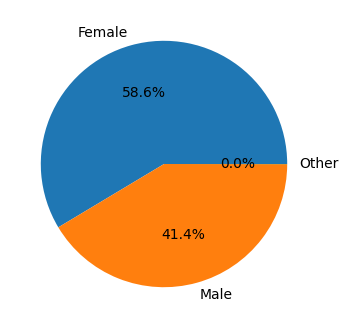

In [82]:
plt.figure(figsize=(6,4))
plt.pie(x=s.values,labels=s.index, autopct='%.1f%%')

in this dataset 58.6% of womans and 41.4% of men are present

AttributeError: module 'matplotlib.pyplot' has no attribute 'tick_labels'

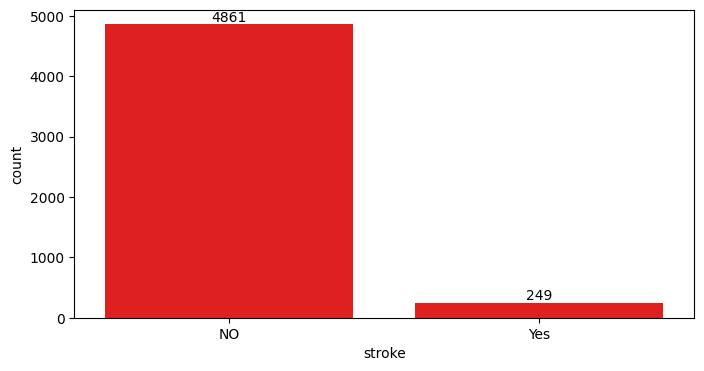

In [ ]:
plt.figure(figsize=(8,4))
o = df['stroke'].value_counts().index
c = sns.countplot(data = df, x = 'stroke', order = o, color = 'red')
c.bar_label(c.containers[0], )
# plt.tick_labels(ticks=[0,1],labels=['affected','not affected'])
plt.show()

This shows overall 249 poeple had stroke

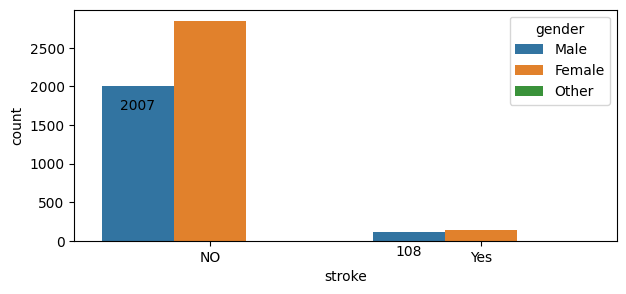

In [ ]:
plt.figure(figsize=(7,3))
o = df['stroke'].value_counts().index
a=sns.countplot(data=df, x='stroke',order = o,hue="gender")
a.bar_label(a.containers[0], padding = -19)
plt.show() 

rate of stroke based on gender

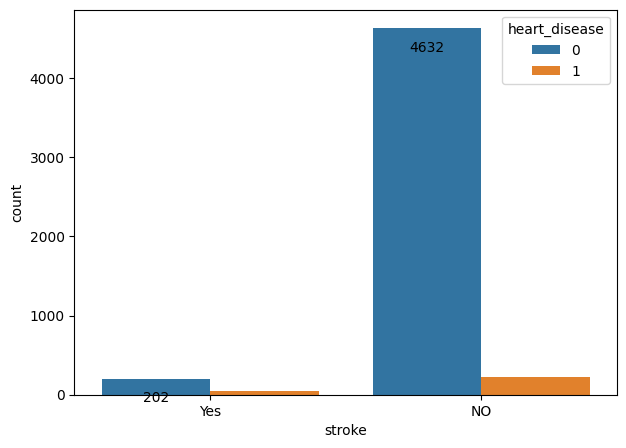

In [ ]:
plt.figure(figsize=(7,5))
r=sns.countplot(data=df, x='stroke',hue="heart_disease")
r.bar_label(r.containers[0], padding = -19)
plt.show() 

the number of people had stroke who were already a heart patient 

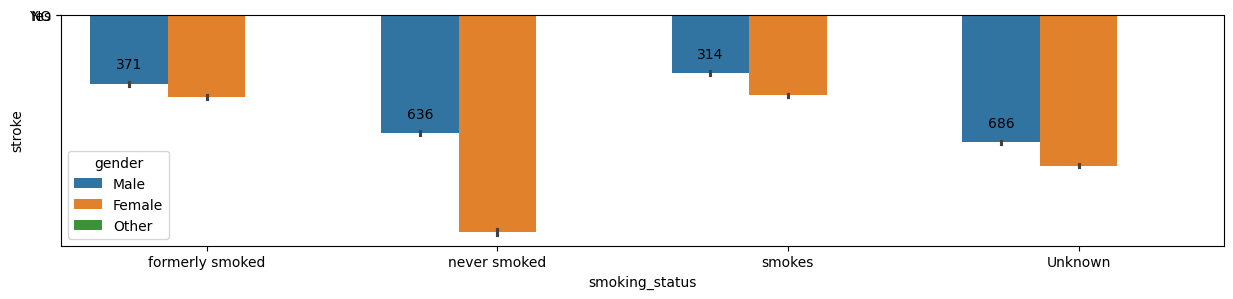

In [ ]:
plt.figure(figsize=(15,3))
v=sns.barplot(data=df, x='smoking_status', y='stroke',estimator='sum',hue='gender')
v.bar_label(v.containers[0], padding = -19)
plt.show()

analysis of stroke  based on peoples smoking behaviour

# final analysis


this data set show that the people who smoke will compared to other people will get stroke and heart reladed deseases